## **Final Project: Recommendation Systems**
##  **Part 2:Content-Based Filtering**

### **Overview**

This notebook implements a **Content-Based Filtering (CBF)** recommendation system using the **MovieLens** dataset.

The system represents movies using:

- genre information
- rating statistics
- TF-IDF tag features

and constructs personalized user profiles from historical ratings.


**The workflow includes:**

1. Data loading and preprocessing
2. Item profile construction
3. User profile construction
4. Recommendation generation using cosine similarity
5. User profile visualization using PCA
6. Leave-one-out evaluation using Precision@10 and Recall@10

In [1]:
# setups and imports
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# **2.0 Load and Prepare the MovieLens Dataset**

In this section, the MovieLens datasets are loaded and basic preprocessing is performed.

Duplicate records are removed and timestamps are converted into readable datetime format to support leave-one-out evaluation later in the notebook.


In [2]:
# loading MovieLens dataset files
DATA_DIR = "ml-latest-small"

# creating full file paths for all csv files
movies_path = os.path.join(DATA_DIR, "movies.csv")
ratings_path = os.path.join(DATA_DIR, "ratings.csv")
tags_path = os.path.join(DATA_DIR, "tags.csv")
links_path = os.path.join(DATA_DIR, "links.csv")


movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)
tags = pd.read_csv(tags_path)
links = pd.read_csv(links_path)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

# previewing first few rows of the movies dataset
movies.head()

Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)
Links shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
#removing duplicate movies based on movieId
movies = movies.drop_duplicates(subset=["movieId"]).copy()
#removing duplicate ratings based on userId, movieId, and timestamp
ratings = ratings.drop_duplicates(subset=["userId", "movieId", "timestamp"]).copy()

# converting UNIX timestamp to datetime to identify each user's last rated movie later
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

print("Number of users:", ratings["userId"].nunique())
print("Number of movies:", movies["movieId"].nunique())
print("Number of ratings:", len(ratings))

Number of users: 610
Number of movies: 9742
Number of ratings: 100836


# **2.1 Item Profile Construction**

Each movie is represented as a numerical feature vector called an **item profile**.

The item profile combines:

- **Genre binary features**: one column per genre, value = 1 if the movie belongs to that genre.
- **Average rating**: the average rating received by the movie.
- **Number of ratings**: how many users rated the movie.
- **Optional tag TF-IDF features**: tags written by users are converted into TF-IDF vectors and concatenated with the item profile.

These features allow movies to be compared numerically using similarity measures.

The final result is an item-feature matrix where each row is a movie and each column is a content feature.


## **Genre Feature Extraction**

Genres are converted into binary one-hot encoded features.

For each genre:

$$
feature_{genre} =
\begin{cases}
1 & \text{if the movie belongs to the genre} \\
0 & \text{otherwise}
\end{cases}
$$

This representation allows genre similarity between movies to be measured mathematically.

In [4]:
# extracting genre features manually
def split_genres(genre_string):
    # handle missing or empty genres
    if pd.isna(genre_string) or genre_string == "(no genres listed)":
        return []
    # split genres using "|"
    return genre_string.split("|")

movies["genre_list"] = movies["genres"].apply(split_genres) # creates a list of genres for each movie

all_genres = sorted(set(g for genres in movies["genre_list"] for g in genres)) # extracts all unique genres
print("Number of unique genres:", len(all_genres))
print(all_genres)

# creating binary genre features
for genre in all_genres:
    movies[genre] = movies["genre_list"].apply(lambda x: 1 if genre in x else 0)

# final genres dataframe
genre_features = movies[["movieId"] + all_genres].copy()
genre_features.head()

Number of unique genres: 19
['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,movieId,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## **Average movie rating & Number of ratings**

These features provide information about movie quality and popularity.

Movies without ratings are assigned:

- Global average rating
- Rating count equal to 0

This helps handle cold-start items.

In [5]:
# Average rating and rating count features

#calculates avg rating and number of ratings for each movie
movie_stats = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

#movies with no rating get neutral values(global average)
global_mean_rating = ratings["rating"].mean()

#merging movie information with binary genre features
item_profiles = movies[["movieId", "title", "genres"]].merge(genre_features, on="movieId", how="left")

#merging item profiles with average rating and rating count features
item_profiles = item_profiles.merge(movie_stats, on="movieId", how="left")

item_profiles["avg_rating"] = item_profiles["avg_rating"].fillna(global_mean_rating)
item_profiles["rating_count"] = item_profiles["rating_count"].fillna(0)

item_profiles.head()

,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),Comedy|Romance,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,3.259615,52.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,2.357143,7.0
4,5,Father of the Bride Part II (1995),Comedy,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.071429,49.0


## **TF-IDF Tag Features**

User-generated movie tags are transformed into numerical TF-IDF features using `TfidfVectorizer`.

TF-IDF increases the importance of informative tags while reducing the effect of overly common words.

The TF-IDF score is computed as:

$$
TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)
$$

where:

$$
IDF(t) = \log\left(\frac{N}{df(t)}\right)
$$

This representation improves semantic understanding of movies beyond genres alone.

Set `USE_TAGS = TRUE` to enable TF-IDF tag feature generation

In [6]:
USE_TAGS = True

# generating TF-IDF features from movie tags
if USE_TAGS:

    # removing rows where tags is empty and cleaning tag text
    tags_clean = tags.dropna(subset=["tag"]).copy()
    tags_clean["tag"] = tags_clean["tag"].astype(str).str.lower().str.strip()

    # combining all tags for each movie into one text string
    movie_tag_text = tags_clean.groupby("movieId")["tag"].apply(
        lambda x: " ".join(x)
    ).reset_index()

    # creating TF-IDF vectorizer for tag text
    tfidf = TfidfVectorizer(
        max_features=50,
        stop_words="english"
    )

    # converting tags into TF-IDF feature vectors
    tag_matrix = tfidf.fit_transform(movie_tag_text["tag"])

    # creating names for TF-IDF feature columns
    tag_feature_names = [
        "tag_" + name
        for name in tfidf.get_feature_names_out()
    ]

    # converting TF-IDF matrix into dataframe
    tag_df = pd.DataFrame(
        tag_matrix.toarray(),
        columns=tag_feature_names
    )

    # adding movieId column for merging
    tag_df["movieId"] = movie_tag_text["movieId"].values


    # removing old tag columns if the cell was run before
    old_tag_cols = [col for col in item_profiles.columns if col.startswith("tag_")]
    item_profiles = item_profiles.drop(columns=old_tag_cols, errors="ignore")

    # merging TF-IDF tag features with item profiles
    item_profiles = item_profiles.merge(
        tag_df,
        on="movieId",
        how="left"
    )

    tag_feature_names = [
        col for col in tag_feature_names
        if col in item_profiles.columns
    ]

    # replacing missing TF-IDF values with 0
    item_profiles[tag_feature_names] = item_profiles[
        tag_feature_names
    ].fillna(0)


print("Number of tag TF-IDF features:", len(tag_feature_names))


item_profiles[item_profiles[tag_feature_names].sum(axis=1) > 0].head()


Number of tag TF-IDF features: 50


,movieId,title,genres,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,rating_count,tag_action,tag_animation,tag_appealing,tag_atmospheric,tag_bad,tag_black,tag_book,tag_business,tag_classic,tag_comedy,tag_crime,tag_dark,tag_dialogue,tag_disney,tag_ending,tag_fi,tag_funny,tag_good,tag_great,tag_high,tag_humor,tag_illness,tag_king,tag_mental,tag_mindfuck,tag_movie,tag_music,tag_netflix,tag_plot,tag_politics,tag_provoking,tag_psychology,tag_queue,tag_quirky,tag_religion,tag_school,tag_sci,tag_shakespeare,tag_soundtrack,tag_space,tag_superhero,tag_surreal,tag_suspense,tag_thought,tag_time,tag_travel,tag_twist,tag_violence,tag_visually,tag_war
10,11,"American President, The (1995)",Comedy|Drama|Romance,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,3.671429,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,14,Nixon (1995),Drama,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3.833333,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,26,Othello (1995),Drama,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3.500000,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,28,Persuasion (1995),Drama|Romance,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,4.227273,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.704811,0.0,0.0,0.0,0.0,0.709395,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
30,31,Dangerous Minds (1995),Drama,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,3.184211,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.710772,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.703422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



## **Final Item Feature Matrix**

All numerical movie features are combined into a final item feature matrix.

The final feature set includes:

- Genre features
- Average rating
- Rating count
- TF-IDF tag features

The `avg_rating` and `rating_count` features are standardized using `StandardScaler` so that large numerical values do not dominate similarity calculations.

Standardization is performed as:

$$
z = \frac{x - \mu}{\sigma}
$$

where:

- \(x\) is the original value
- \(mu\) is the feature mean
- \(sigma\) is the standard deviation

In [7]:
# creating list of all numerical item profile features
feature_columns = all_genres + ["avg_rating", "rating_count"] + tag_feature_names

# scaling avg_rating and rating_count so they do not dominate genre features
item_features_raw = item_profiles[feature_columns].copy()

scaler = StandardScaler()
item_features_scaled = item_features_raw.copy()
item_features_scaled[["avg_rating", "rating_count"]] = scaler.fit_transform(
    item_features_scaled[["avg_rating", "rating_count"]]
)

# creating final numerical item feature matrix indexed by movieId
item_feature_matrix = pd.DataFrame(
    item_features_scaled.values,
    index=item_profiles["movieId"],
    columns=feature_columns
)

print("Item feature matrix shape:", item_feature_matrix.shape)
item_feature_matrix.head()

Item feature matrix shape: (9742, 71)


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,rating_count,tag_action,tag_animation,tag_appealing,tag_atmospheric,tag_bad,tag_black,tag_book,tag_business,tag_classic,tag_comedy,tag_crime,tag_dark,tag_dialogue,tag_disney,tag_ending,tag_fi,tag_funny,tag_good,tag_great,tag_high,tag_humor,tag_illness,tag_king,tag_mental,tag_mindfuck,tag_movie,tag_music,tag_netflix,tag_plot,tag_politics,tag_provoking,tag_psychology,tag_queue,tag_quirky,tag_religion,tag_school,tag_sci,tag_shakespeare,tag_soundtrack,tag_space,tag_superhero,tag_surreal,tag_suspense,tag_thought,tag_time,tag_travel,tag_twist,tag_violence,tag_visually,tag_war
movieId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.757164,9.142834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.194375,4.451895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.003768,1.860710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.042184,-0.149692,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.220302,1.726683,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **2.2 User Profile Construction**

A user profile is constructed as a weighted combination of movie feature vectors.

Movies rated above the neutral rating contribute positively to the profile, while movies rated below the neutral rating contribute negatively.

The user profile vector is computed as:

$$
\vec{u} =
\frac{\sum_i w_i \vec{m_i}}
{\sum_i |w_i|}
$$

where:

- \(vec{u}\) is the user profile vector
- \(vec{m_i}\) is the feature vector of movie \(i\)
- \(w_i = rating_i - 3\)

This allows the profile to capture each user's movie preferences numerically.

In [8]:
# creating user profile vectors from rated movie features
def build_user_profiles(ratings_df, item_matrix, neutral_rating=3.0):

    user_profiles = {}

    for user_id, user_ratings in ratings_df.groupby("userId"):

        # get movies rated by the user
        movie_ids = user_ratings["movieId"].values

        # keep only movies in item feature matrix
        valid_movie_ids = [mid for mid in movie_ids if mid in item_matrix.index]

        # skip user with no valid movie
        if len(valid_movie_ids) == 0:
            continue

        user_ratings = user_ratings[user_ratings["movieId"].isin(valid_movie_ids)].copy()

        # shifting ratings around neutral value (3)
        weights = user_ratings["rating"].values - neutral_rating

        # getting feature vectors of rated movies
        item_vectors = item_matrix.loc[user_ratings["movieId"].values].values

        denominator = np.sum(np.abs(weights)) # normalization denominator

        if denominator == 0:
            # if all ratings are neutral,simple average is used
            profile = item_vectors.mean(axis=0)
        else:
            profile = np.dot(weights, item_vectors) / denominator

        user_profiles[user_id] = profile

    return pd.DataFrame.from_dict(user_profiles, orient="index", columns=item_matrix.columns)

user_profiles = build_user_profiles(ratings, item_feature_matrix)

print("User profile matrix shape:", user_profiles.shape)
user_profiles.head()

User profile matrix shape: (610, 71)


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,rating_count,tag_action,tag_animation,tag_appealing,tag_atmospheric,tag_bad,tag_black,tag_book,tag_business,tag_classic,tag_comedy,tag_crime,tag_dark,tag_dialogue,tag_disney,tag_ending,tag_fi,tag_funny,tag_good,tag_great,tag_high,tag_humor,tag_illness,tag_king,tag_mental,tag_mindfuck,tag_movie,tag_music,tag_netflix,tag_plot,tag_politics,tag_provoking,tag_psychology,tag_queue,tag_quirky,tag_religion,tag_school,tag_sci,tag_shakespeare,tag_soundtrack,tag_space,tag_superhero,tag_surreal,tag_suspense,tag_thought,tag_time,tag_travel,tag_twist,tag_violence,tag_visually,tag_war
1,0.359517,0.356495,0.148036,0.196375,0.320242,0.184290,0.000000,0.314199,0.184290,0.006042,0.024169,0.000000,0.111782,0.063444,0.102719,0.148036,0.190332,0.099698,0.027190,0.455192,2.598453,0.011599,0.010378,0.000000,0.000660,0.000000,-0.001003,0.002815,0.002172,0.014181,0.018991,0.005486,0.017019,0.002374,0.037406,0.016345,0.013768,0.001078,0.000000,0.003578,0.000000,0.013394,0.000757,0.021125,0.000765,0.005483,0.002100,0.004941,0.002129,0.003606,0.015573,0.009247,-0.001950,0.002143,0.005486,0.016067,0.006042,0.013768,0.006042,0.001756,0.013188,0.016939,0.000730,0.003210,0.009247,0.007080,0.007003,0.018603,0.007472,0.000000,0.009063
2,0.344262,0.114754,0.000000,0.000000,0.229508,0.262295,0.131148,0.491803,0.000000,0.000000,0.000000,0.098361,0.000000,0.065574,0.049180,0.114754,0.229508,0.049180,0.016393,0.833414,2.123713,0.009861,0.000000,0.058219,0.011129,0.000000,0.037574,0.008531,0.046368,0.000000,0.050186,0.049180,0.026788,0.000000,0.000000,0.020123,0.005506,0.067017,0.004434,0.018405,0.000000,0.000000,0.000000,0.000000,0.000000,0.005788,0.000000,0.022975,0.000000,0.016932,0.046368,0.032627,0.035103,0.000000,0.000000,0.000000,0.000000,0.005506,0.000000,0.019951,0.000000,0.036754,0.005412,0.054229,0.032627,0.000000,0.000000,0.029173,0.000000,0.056643,0.000000
3,0.100000,-0.037500,-0.125000,-0.156250,-0.225000,-0.062500,0.000000,-0.450000,0.018750,0.000000,0.168750,0.000000,-0.031250,0.025000,-0.156250,0.225000,0.100000,-0.156250,0.000000,0.157955,-0.925503,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.031250,0.000000,0.000000,0.000000,0.000000,0.000000,-0.044423,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.031250,0.000000,0.000000,0.000000,-0.022097,-0.031250,0.000000,0.000000,0.000000,-0.043964,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.022097,0.000000,0.000000,0.000000,0.000000,0.000000,-0.062500
4,0.030303,0.071970,0.022727,0.030303,0.200758,0.083333,0.007576,0.219697,0.049242,0.015152,0.018939,0.000000,0.060606,0.041667,0.083333,-0.007576,0.079545,0.015152,0.030303,0.461271,0.693813,0.000353,0.000000,0.000000,0.000842,-0.001512,0.001845,0.001757,0.000000,0.005417,0.004918,0.002023,0.002352,0.001595,0.021556,-0.000565,0.000738,-0.000300,0.001804,0.002861,0.000000,-0.001069,-0.000475,0.012383,-0.000479,-0.000175,-0.000492,0.012763,0.024028,0.002019,0.003788,0.001820,0.008427,0.024184,-0.006012,0.011364,0.000000,0.000738,0.003788,-0.000784,0.008960,0.000000,-0.000458,0.007000,0.001820,-0.002503,-0.002476,-0.000591,-0.004248,0.000000,0.007576
5,0.026316,0.052632,0.210526,0.263158,0.184211,0.263158,0.000000,0.526316,0.210526,0.000000,0.000000,0.052632,0.184211,0.026316,0.026316,-0.026316,0.131579,0.026316,0.000000,0.577873,3.427303,0.007131,0.000000,0.000000,0.003139,0.010506,0.010599,0.000000,0.000000,0.011714,0.008950,0.013890,0.009697,0.019813,0.184211,0.016096,0.000000,0.006782,0.030288,0.014541,0.000000,0.007427,0.000000,0.000000,0.000000,0.013642,0.021341,0.007004,0.074191,0.003714,0.000000,0.040749,0.000000,0.074673,0.003472,0.000000,0.000000,0.000000,0.000000,0.015406,0.000000,0.000000,0.000000,0.016662,0.040749,-0.018709,-0.018506,0.016822,0.027738,0.000000,0.000000


## **PCA Visualization of User Profiles**

Principal Component Analysis (**PCA**) is used to reduce high-dimensional user profiles into two dimensions for visualization.

PCA projects users into a lower-dimensional space while preserving as much variance as possible.

Users with similar preferences tend to appear closer together, forming loose clusters in the PCA plot.

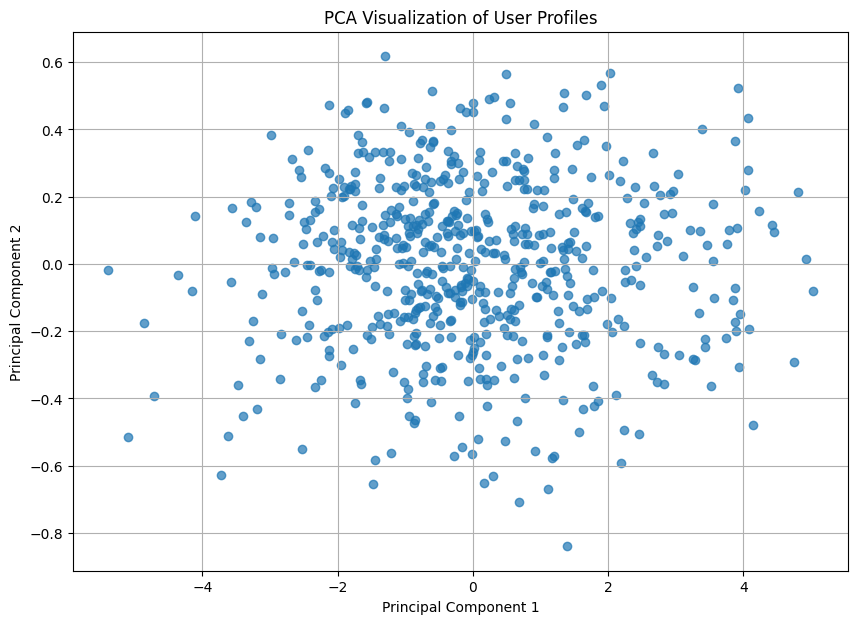

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reducing user profile vectors to 2 dimensions using PCA
pca = PCA(n_components=2)

user_profiles_2d = pca.fit_transform(user_profiles)

# creating dataframe containing PCA coordinates
pca_df = pd.DataFrame(
    user_profiles_2d,
    columns=["PC1", "PC2"],
    index=user_profiles.index
)

# plotting user profiles in 2D PCA space
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.7
)

plt.title("PCA Visualization of User Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)
plt.show()

# **2.3 Recommendation using Cosine Similarity**

Recommendations are generated by computing cosine similarity between each user profile vector and all unrated movie vectors.

Cosine similarity measures the angle between two vectors:

$$
\text{cosine similarity}(A,B) =
\frac{A \cdot B}{||A||\ ||B||}
$$

Similarity values closer to 1 indicate stronger preference alignment.

Movies with the highest similarity scores are recommended to the user.

In [10]:
def recommend_content_based(user_id, ratings_df, item_matrix, user_profile_df, movies_df, top_n=10):

    if user_id not in user_profile_df.index:
        raise ValueError(f"User {user_id} does not have a profile.")

    # getting the target user's profile vector
    user_vector = user_profile_df.loc[user_id].values.reshape(1, -1)

    # computing cosine similarity betn the user profile and all item profiles
    similarities = cosine_similarity(user_vector, item_matrix.values).flatten()

    scores = pd.DataFrame({
        "movieId": item_matrix.index,
        "content_score": similarities
    })

    #removing movies already rated by user
    rated_movies = set(ratings_df.loc[ratings_df["userId"] == user_id, "movieId"])
    scores = scores[~scores["movieId"].isin(rated_movies)]

    #sorting movies by similarity score and keeping top N recommendations
    recommendations = (
        scores.sort_values("content_score", ascending=False)
        .head(top_n)
        .merge(movies_df[["movieId", "title", "genres"]], on="movieId", how="left")
    )

    return recommendations[["movieId", "title", "genres", "content_score"]]

# recommending top 10 movies for 3 example users
example_users = list(user_profiles.index[:3])
for uid in example_users:
    print(f"\nTop 10 content-based recommendations for User {uid}")
    display(recommend_content_based(uid, ratings, item_feature_matrix, user_profiles, movies, top_n=10))


Top 10 content-based recommendations for User 1


,movieId,title,genres,content_score
0,6539,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,0.972952
1,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,0.970400
2,380,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller,0.966961
3,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.962509
4,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,0.961517
5,858,"Godfather, The (1972)",Crime|Drama,0.961330
6,1527,"Fifth Element, The (1997)",Action|Adventure|Comedy|Sci-Fi,0.960918
7,10,GoldenEye (1995),Action|Adventure|Thriller,0.959407
8,1968,"Breakfast Club, The (1985)",Comedy|Drama,0.958763
9,1036,Die Hard (1988),Action|Crime|Thriller,0.957693



Top 10 content-based recommendations for User 2


,movieId,title,genres,content_score
0,1225,Amadeus (1984),Drama,0.961162
1,1213,Goodfellas (1990),Crime|Drama,0.958096
2,1221,"Godfather: Part II, The (1974)",Crime|Drama,0.957769
3,111,Taxi Driver (1976),Crime|Drama|Thriller,0.954470
4,7438,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller,0.951911
5,2959,Fight Club (1999),Action|Crime|Drama|Thriller,0.950916
6,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,0.950707
7,1208,Apocalypse Now (1979),Action|Drama|War,0.950129
8,81845,"King's Speech, The (2010)",Drama,0.947322
9,1207,To Kill a Mockingbird (1962),Drama,0.947067



Top 10 content-based recommendations for User 3


,movieId,title,genres,content_score
0,141866,Green Room (2015),(no genres listed),0.808439
1,181719,Serving in Silence: The Margarethe Cammermeyer...,(no genres listed),0.743573
2,171891,Generation Iron 2,(no genres listed),0.743573
3,155589,Noin 7 veljestä (1968),(no genres listed),0.567207
4,114335,La cravate (1957),(no genres listed),0.567207
5,6836,"Amazing Transparent Man, The (1960)",Sci-Fi,0.505795
6,77795,Cargo (2009),Sci-Fi,0.505795
7,6899,Alien from L.A. (1988),Sci-Fi,0.505795
8,149330,A Cosmic Christmas (1977),(no genres listed),0.475396
9,167570,The OA,(no genres listed),0.475396



# **Leave-One-Out Evaluation**

The recommender system is evaluated using leave-one-out cross-validation.

For each user:

1. The user's latest rated movie is hidden
2. The remaining ratings are used for training
3. Top-10 recommendations are generated
4. The hidden movie is checked against the recommendation list

## **Precision@10 and Recall@10**

Evaluation performance is measured using Precision@10 and Recall@10.

Precision@10 measures the proportion of recommended movies that were relevant:

$$
Precision@10 =
\frac{Hits}{Users \times 10}
$$

Recall@10 measures how often the hidden movie was recovered in the top-10 list:

$$
Recall@10 =
\frac{Hits}{Users}
$$

Higher values indicate better recommendation quality.

In [11]:
# spliting ratings into training and hidden test sets

def leave_one_out_split(ratings_df):
    # sorting ratings by userid and timestamp
    ratings_sorted = ratings_df.sort_values(["userId", "timestamp"])

    # selecting last rating of each user as test data
    test_idx = ratings_sorted.groupby("userId").tail(1).index

    test = ratings_sorted.loc[test_idx].copy() # creating hidden test set

    train = ratings_sorted.drop(test_idx).copy() # use remaining for training set

    return train, test

train_ratings, loo_test = leave_one_out_split(ratings)

print("Train ratings:", train_ratings.shape)
print("Hidden test ratings:", loo_test.shape)
loo_test.head()

Train ratings: (100226, 5)
Hidden test ratings: (610, 5)


,userId,movieId,rating,timestamp,datetime
161,1,2492,4.0,965719662,2000-08-08 07:27:42
247,2,80489,4.5,1445715340,2015-10-24 19:35:40
281,3,2424,0.5,1306464293,2011-05-27 02:44:53
502,4,4246,4.0,1007574542,2001-12-05 17:49:02
545,5,474,4.0,847435337,1996-11-08 06:42:17


In [12]:
# build user profiles using only training ratings
train_user_profiles = build_user_profiles(
    train_ratings,
    item_feature_matrix)

print("Train user profiles:", train_user_profiles.shape)

Train user profiles: (610, 71)


In [13]:
def evaluate_leave_one_out(train_ratings, test_ratings, item_matrix, user_profile_df, movies_df,k=10):

    hits = 0
    evaluated_users = 0
    hit_details = []

    # evaluating each hidden test movie
    for _, row in test_ratings.iterrows():
        user_id = row["userId"]
        hidden_movie = row["movieId"]

        # skiping users without profiles
        if user_id not in user_profile_df.index:
            continue

        # generating top k recommendations
        recs = recommend_content_based(
            user_id=user_id,
            ratings_df=train_ratings,
            item_matrix=item_matrix,
            user_profile_df=user_profile_df,
            movies_df=movies_df,
            top_n=k
        )

        # checking whether hidden movie appears in recommendations
        recommended_movies = set(recs["movieId"])
        # update hit counters
        hit = int(hidden_movie in recommended_movies)
        hits += hit
        evaluated_users += 1

        hit_details.append({
            "userId": user_id,
            "hidden_movieId": hidden_movie,
            "hidden_rating": row["rating"],
            "hit": hit
        })

    precision_at_k = hits / (evaluated_users * k) if evaluated_users > 0 else 0
    recall_at_k = hits / evaluated_users if evaluated_users > 0 else 0

    return precision_at_k, recall_at_k, pd.DataFrame(hit_details)

# running leave-one-out evaluation
precision_10, recall_10, loo_results = evaluate_leave_one_out(
    train_ratings=train_ratings,
    test_ratings=loo_test,
    item_matrix=item_feature_matrix,
    user_profile_df=train_user_profiles,
    movies_df=movies,
    k=10
)

print(f"Precision@10: {precision_10:.4f}")
print(f"Recall@10: {recall_10:.4f}")
print("Number of hits:", loo_results["hit"].sum())
print("Number of evaluated users:", len(loo_results))

loo_results.head()

Precision@10: 0.0036
Recall@10: 0.0361
Number of hits: 22
Number of evaluated users: 610


,userId,hidden_movieId,hidden_rating,hit
0,1,2492,4.0,0
1,2,80489,4.5,0
2,3,2424,0.5,0
3,4,4246,4.0,0
4,5,474,4.0,0


## **Evaluation Discussion**

The content-based recommender successfully captures some meaningful preference patterns using genres, rating statistics, and TF-IDF tag features.

However, recommendation performance remains limited because:

- User interactions are sparse
- Some movies contain missing metadata
- Content-based filtering does not use collaborative user behavior
- Users may watch movies from diverse genres

Despite these limitations, the system demonstrates the core principles of personalized content-based recommendation.


# **Final Notes for Part 2**

This notebook completed the required Content-Based Filtering pipeline:

- Item profile construction
- User profile construction
- Recommendation generation
- PCA visualization
- Leave-one-out evaluation

The resulting recommender system demonstrates how movie metadata and user preferences can be combined to generate personalized movie recommendations.